In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

house_df = pd.read_csv(r"C:\Users\marti\Downloads\archive\Housing.csv")

house_df.head()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,yes,yes,yes,no,yes,2,no,furnished


In [2]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   mainroad          545 non-null    object
 5   guestroom         545 non-null    object
 6   basement          545 non-null    object
 7   hotwaterheating   545 non-null    object
 8   airconditioning   545 non-null    object
 9   parking           545 non-null    int64 
 10  prefarea          545 non-null    object
 11  furnishingstatus  545 non-null    object
dtypes: int64(5), object(7)
memory usage: 51.2+ KB


In [3]:
house_df.isnull()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
house_df.isnull().sum().sort_values(ascending = False)

price               0
area                0
bedrooms            0
bathrooms           0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
house_df.describe()

,price,area,bedrooms,bathrooms,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,3.000000


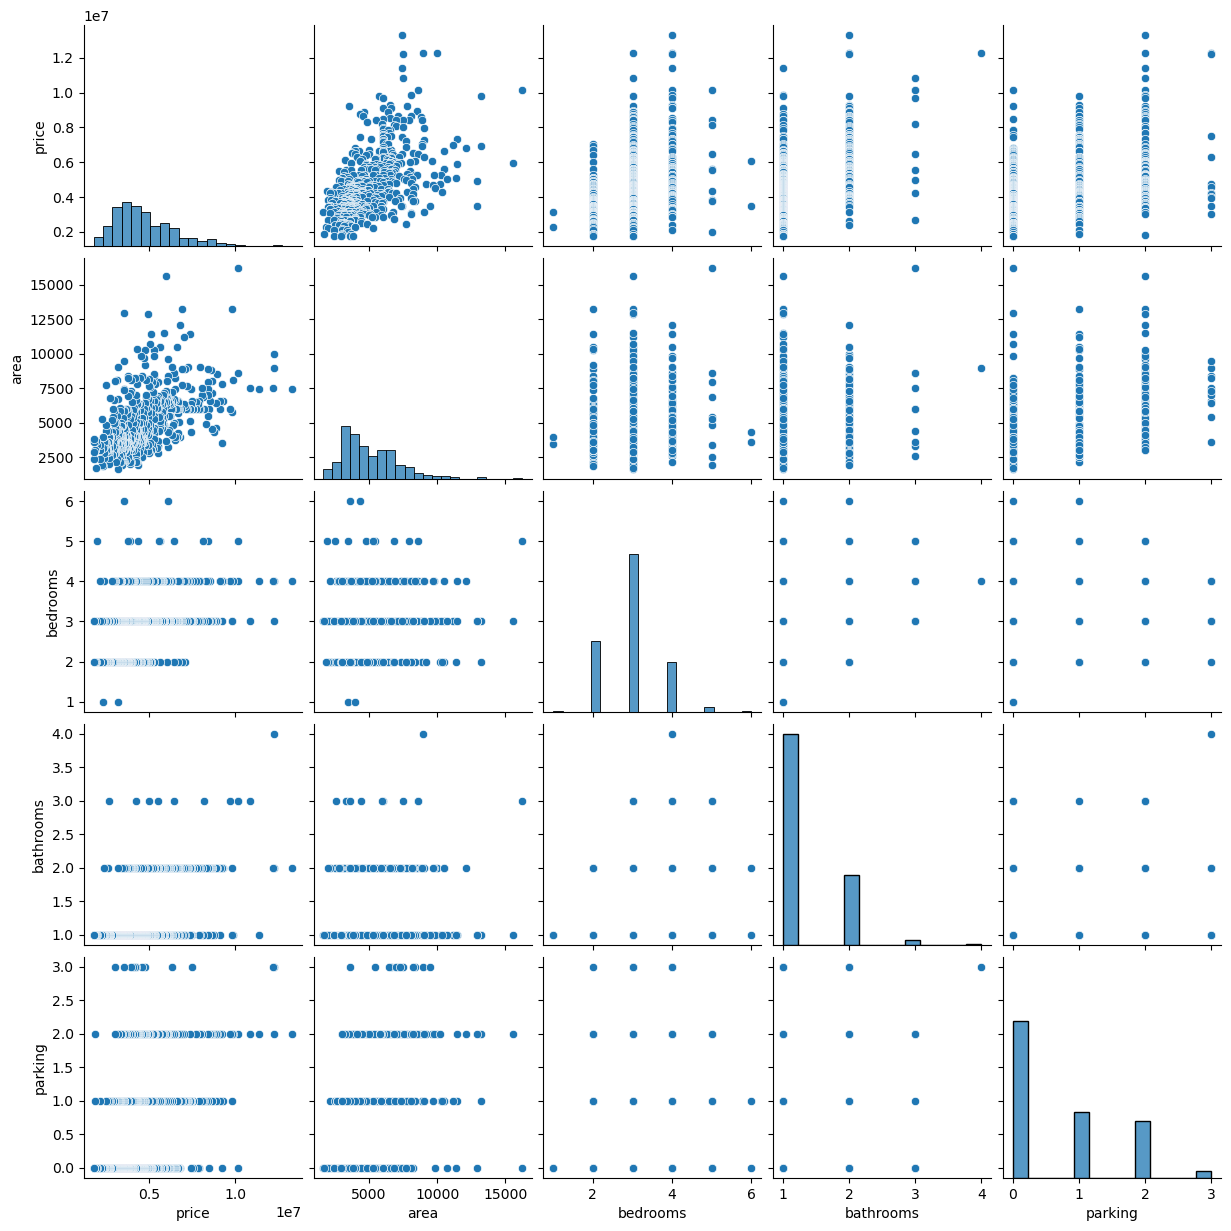

In [6]:
sns.pairplot(house_df)
plt.show()

In [7]:
house_df.corr(numeric_only = True)["price"].sort_values(ascending = False)

price        1.000000
area         0.535997
bathrooms    0.517545
parking      0.384394
bedrooms     0.366494
Name: price, dtype: float64

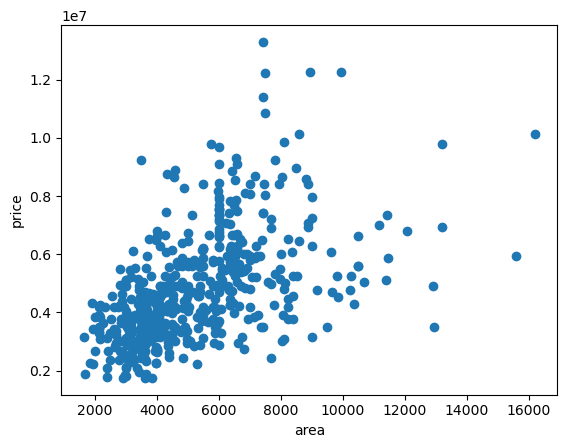

In [8]:
plt.scatter(house_df["area"], house_df["price"])
plt.xlabel("area")
plt.ylabel("price")
plt.show()

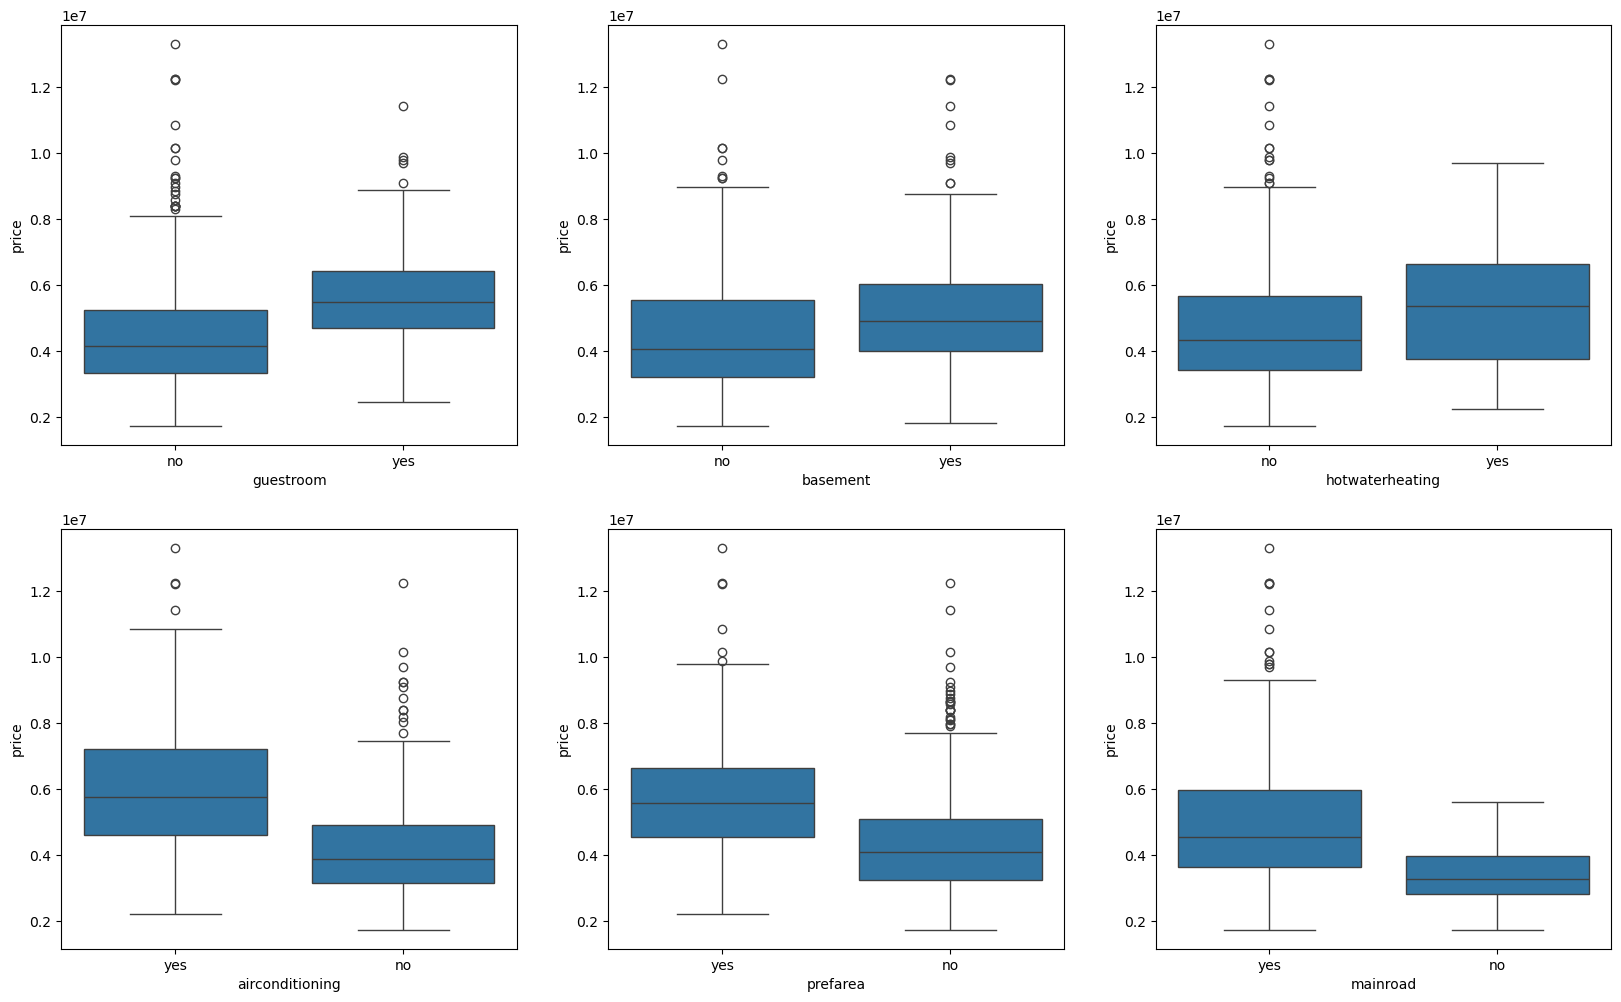

In [9]:
plt.figure(figsize=(20, 12))


plt.subplot(2, 3, 1)
sns.boxplot(x = 'guestroom', y = 'price', data = house_df)

plt.subplot(2, 3, 2)
sns.boxplot(x = 'basement', y = 'price', data = house_df)

plt.subplot(2, 3, 3)
sns.boxplot(x = 'hotwaterheating', y = 'price', data = house_df)

plt.subplot(2, 3, 4)
sns.boxplot(x = 'airconditioning', y = 'price', data = house_df)

plt.subplot(2, 3, 5)
sns.boxplot(x = 'prefarea', y = 'price', data = house_df)

plt.subplot(2, 3, 6)
sns.boxplot(x = 'mainroad', y = 'price', data = house_df)

plt.show()

In [13]:
varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

house_df[varlist] = house_df[varlist].apply(lambda x: x.map({'yes': 1, 'no': 0}))
house_df[varlist].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [14]:
status = pd.get_dummies(house_df['furnishingstatus'])
status = status.astype(int)
status.head()

,furnished,semi-furnished,unfurnished
0,1,0,0
1,1,0,0
2,0,1,0
3,1,0,0
4,1,0,0


In [15]:
status = pd.get_dummies(house_df['furnishingstatus'], drop_first = True)
status = status.astype(int)
status.head()

,semi-furnished,unfurnished
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0


In [18]:
house_df = house_df.drop('furnishingstatus', axis=1)
house_df.head()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,13300000,7420,4,2,1,0,0,0,1,2,1
1,12250000,8960,4,4,1,0,0,0,1,3,0
2,12250000,9960,3,2,1,0,1,0,0,2,1
3,12215000,7500,4,2,1,0,1,0,1,3,1
4,11410000,7420,4,1,1,1,1,0,1,2,0


In [20]:
house_df = pd.concat([house_df, status], axis = 1)
house_df.head()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,1,1,1,0,1,2,0,0,0


In [21]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score

In [22]:
house_df_train, house_df_test = train_test_split(house_df, train_size = 0.7, random_state = 100)

print(house_df_train.shape)
print(house_df_test.shape)

(381, 13)
(164, 13)


In [23]:
scaler = MinMaxScaler()

num_vars = ['price', 'area', 'bedrooms', 'bathrooms', 'parking']

house_df_train[num_vars] = scaler.fit_transform(house_df_train[num_vars])
house_df_train.head()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.155227,0.4,0.0,1,0,0,0,0,0.333333,0,0,1
19,0.615152,0.403379,0.4,0.5,1,0,0,0,1,0.333333,1,1,0
159,0.321212,0.115628,0.4,0.5,1,1,1,0,1,0.000000,0,0,0
35,0.548133,0.454417,0.4,0.5,1,0,0,0,1,0.666667,0,0,0
28,0.575758,0.538015,0.8,0.5,1,0,1,1,0,0.666667,0,0,1


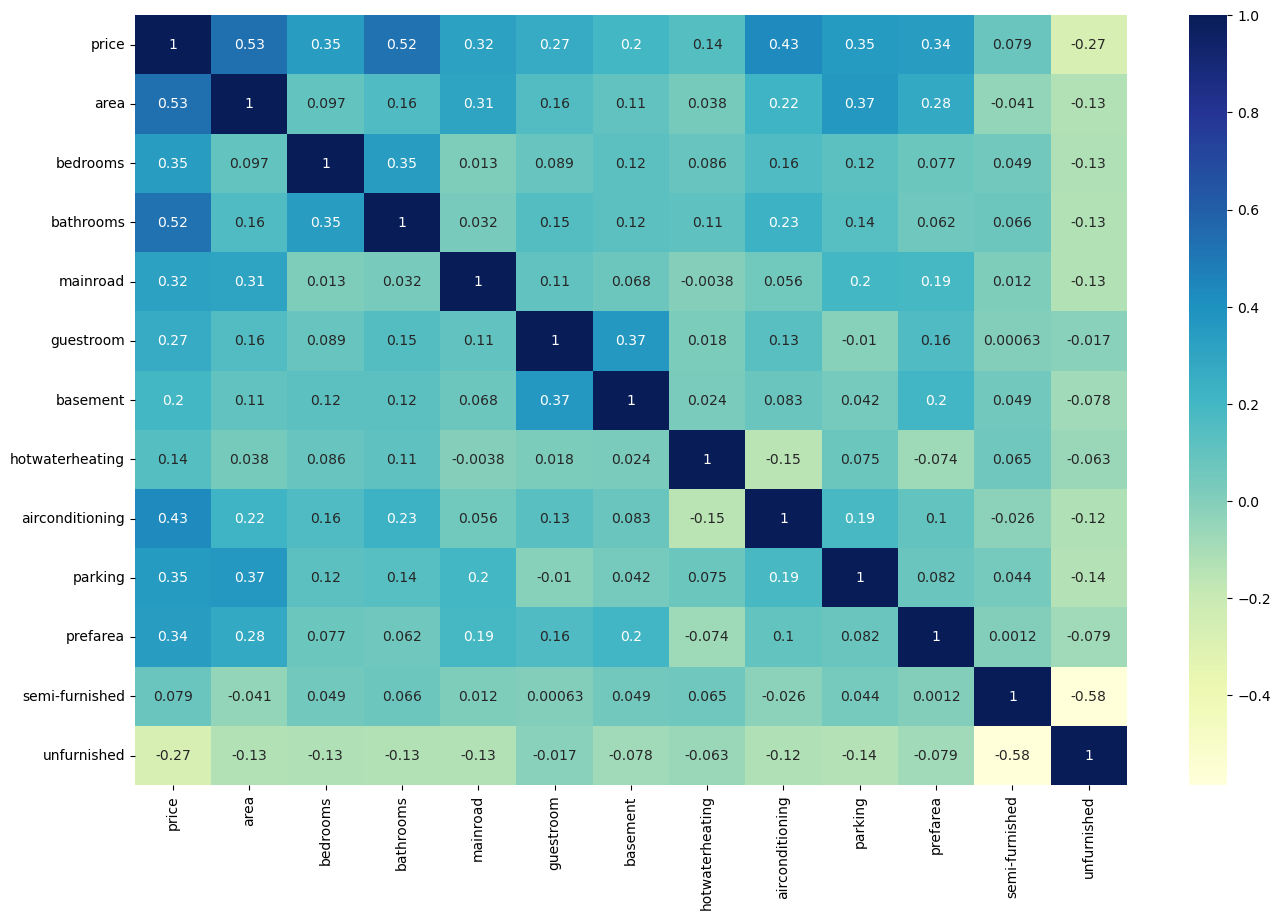

In [24]:
plt.figure(figsize=(16, 10))
sns.heatmap(house_df_train.corr(), annot=True, cmap = 'YlGnBu')
plt.show()

In [25]:
house_df_train.head()

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
359,0.169697,0.155227,0.4,0.0,1,0,0,0,0,0.333333,0,0,1
19,0.615152,0.403379,0.4,0.5,1,0,0,0,1,0.333333,1,1,0
159,0.321212,0.115628,0.4,0.5,1,1,1,0,1,0.000000,0,0,0
35,0.548133,0.454417,0.4,0.5,1,0,0,0,1,0.666667,0,0,0
28,0.575758,0.538015,0.8,0.5,1,0,1,1,0,0.666667,0,0,1


In [26]:
y_train = house_df_train.pop('price')
X_train = house_df_train

In [27]:
y_train.head()

359    0.169697
19     0.615152
159    0.321212
35     0.548133
28     0.575758
Name: price, dtype: float64

In [28]:
X_train_sm = sm.add_constant(X_train['area'])

# Create first model
lr = sm.OLS(y_train, X_train_sm)

# Fit
lr_model = lr.fit()

# Params
lr_model.params

const    0.126894
area     0.462192
dtype: float64

In [29]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.283
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     149.6
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           3.15e-29
Time:                        10:07:22   Log-Likelihood:                 227.23
No. Observations:                 381   AIC:                            -450.5
Df Residuals:                     379   BIC:                            -442.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1269      0.013      9.853      0.000       0.102       0.152
area           0.4622      0.038     12.232      0.000       0.388       0.536
==============================================================================
Omnibus:                       67.313   Durbin-Watson:                   2.018
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              143.063
Skew:                           0.925   Prob(JB):                     8.59e-32
Kurtosis:                       5.365   Cond. No.                         5.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
house_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'semi-furnished', 'unfurnished'],
      dtype='object')

In [31]:
X_train_sm = sm.add_constant(X_train)

lr = sm.OLS(y_train, X_train_sm)

lr_model = lr.fit()

lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     57.88
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.24e-77
Time:                        10:19:07   Log-Likelihood:                 365.84
No. Observations:                 381   AIC:                            -705.7
Df Residuals:                     368   BIC:                            -654.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0112      0.022      0.512      0.609      -0.032       0.054
area                0.2270      0.031      7.250      0.000       0.165       0.289
bedrooms            0.1265      0.036      3.563      0.000       0.057       0.196
bathrooms           0.2117      0.023      9.379      0.000       0.167       0.256
mainroad            0.0632      0.015      4.289      0.000       0.034       0.092
guestroom           0.0361      0.014      2.550      0.011       0.008       0.064
basement            0.0034      0.011      0.306      0.759      -0.018       0.025
hotwaterheating     0.0849      0.022      3.781      0.000       0.041       0.129
airconditioning     0.0816      0.011      7.096      0.000       0.059       0.104
parking             0.0492      0.019      2.637      0.009       0.013       0.086
prefarea            0.0632      0.012      5.153      0.000       0.039       0.087
semi-furnished     -0.0009      0.012     -0.072      0.943      -0.025       0.023
unfurnished        -0.0331      0.013     -2.500      0.013      -0.059      -0.007
==============================================================================
Omnibus:                       76.606   Durbin-Watson:                   2.089
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              201.674
Skew:                           0.960   Prob(JB):                     1.61e-44
Kurtosis:                       6.003   Cond. No.                         13.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""